# Week 5 -- Data Exploration: Visualization & EDA
### CSE 432/532 -- Machine Learning

**What we will cover today:**

| # | Topic | Book Section |
|---|-------|--------------|
| 1 | Visualizing data with one feature | 5.1 |
| 2 | Visualizing data with multiple features | 5.2 |
| 3 | Best practices for visualizing data | 5.3 |
| 4 | Exploratory Data Analysis (EDA) | 5.5 |
| 5 | Detecting outliers | 5.6 |


---

In [1]:
# -- Setup -----------------------------------------------
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set a clean seaborn style
sns.set_theme(style='whitegrid')

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## Part 1: Visualizing Data with One Feature (Section 5.1)

The simplest case: we have **one feature** and want to understand its distribution.

- **Categorical feature**: divides data into groups/categories --> **bar chart**
- **Numerical feature**: values vary continuously --> **histogram, density plot, box plot**

We will use the **country dataset** (Gapminder data) that the book uses.

In [2]:
# Load a dataset -- we will use the gapminder-style data
# seaborn does not ship gapminder, so let's build a similar one
# We will use the tips dataset (from the book) and also create a country-style one

tips = sns.load_dataset('tips')  # used in book Section 5.2
print('Tips dataset shape:', tips.shape)
tips.head()

Tips dataset shape: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### 1.1 Visualizing a Categorical Feature: Bar Chart

A **bar chart** has groups on one axis and rectangles whose heights represent the count (or proportion) of items in that group.

Let's look at which **day** customers visit the restaurant most.

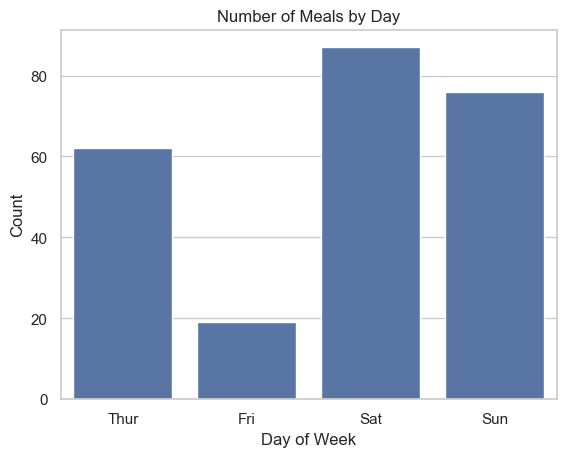

In [35]:
# Bar chart: count of meals per day
#sns.countplot(data=tips, x='day', order=['Thur', 'Fri', 'Sat', 'Sun'])
sns.countplot(data=tips, x='day')
plt.title('Number of Meals by Day')
plt.xlabel('Day of Week')
plt.ylabel('Count')
plt.show()

**Relative frequency bar chart**: same shape, but the y-axis shows proportions instead of counts.  
Useful when comparing groups of different sizes.

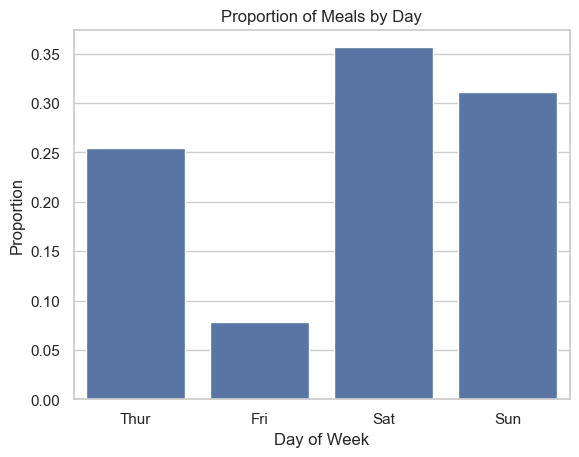

In [4]:
# Relative frequency: we compute proportions ourselves
day_counts = tips['day'].value_counts()
day_props = day_counts / len(tips)
day_props = day_props.reindex(['Thur', 'Fri', 'Sat', 'Sun'])

sns.barplot(x=day_props.index, y=day_props.values)
plt.title('Proportion of Meals by Day')
plt.xlabel('Day of Week')
plt.ylabel('Proportion')
plt.show()

### 1.2 Visualizing a Numerical Feature

For numerical features, we have three main tools:

| Plot Type | What it shows |
|-----------|---------------|
| **Histogram** | Divides values into bins and counts how many fall in each bin |
| **Density plot (KDE)** | Smooth approximation of the distribution (think: smoothed histogram) |
| **Box plot** | Five-number summary: min, Q1, median, Q3, max |

Let's start with the **total_bill** feature from the tips dataset.

#### From Histogram to Density Curve (PDF)

**Key idea:** If we keep *decreasing the bin width* of a histogram, the shape starts to resemble a smooth curve -- this is the **probability density function (PDF)**.

Let's see this in action!

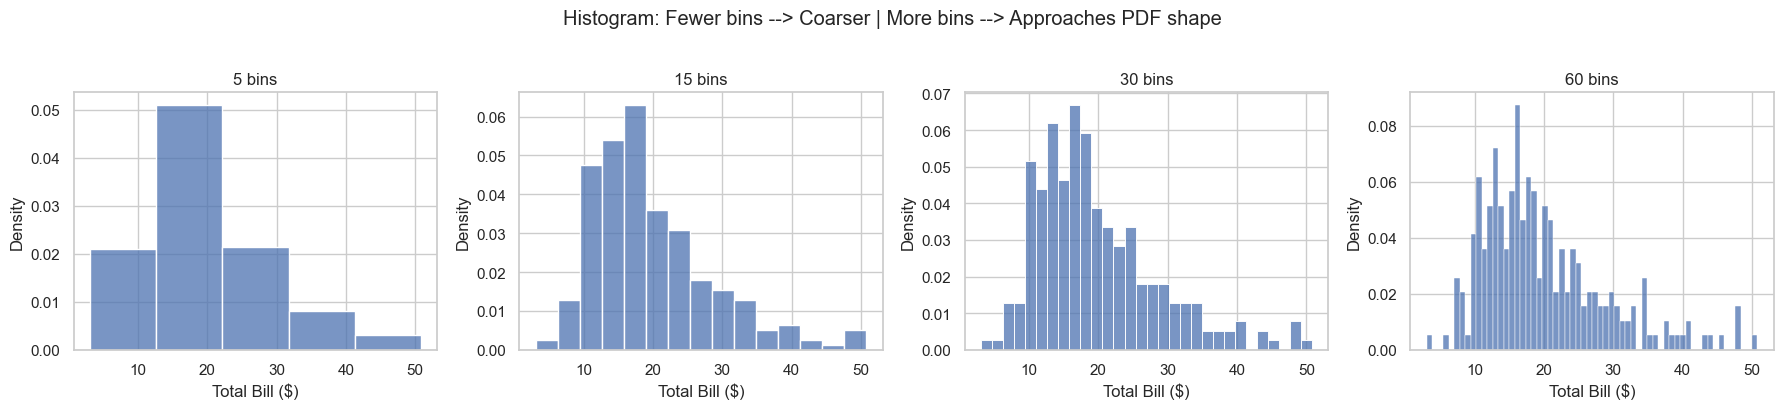

In [5]:
# Histogram with different numbers of bins
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

bin_counts = [5, 15, 30, 60]

for ax, bins in zip(axes, bin_counts):
    sns.histplot(data=tips, x='total_bill', bins=bins, stat='density', ax=ax)
    ax.set_title(f'{bins} bins')
    ax.set_xlabel('Total Bill ($)')
    ax.set_ylabel('Density')

plt.suptitle('Histogram: Fewer bins --> Coarser | More bins --> Approaches PDF shape', y=1.02)
plt.tight_layout()
plt.show()

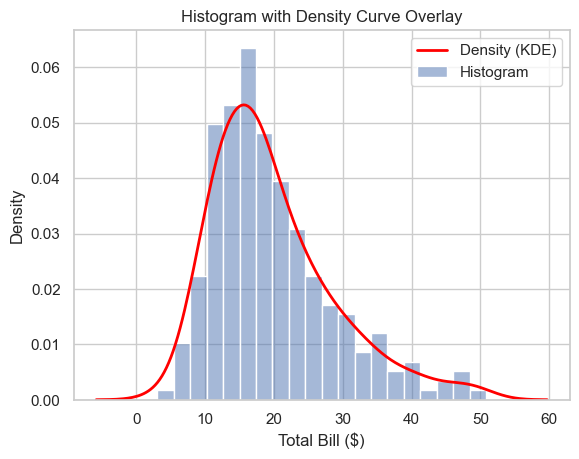

In [6]:
# Now overlay the density curve (KDE) on top of the histogram
sns.histplot(data=tips, x='total_bill', bins=20, stat='density', alpha=0.5, label='Histogram')
sns.kdeplot(data=tips, x='total_bill', color='red', linewidth=2, label='Density (KDE)')
plt.title('Histogram with Density Curve Overlay')
plt.xlabel('Total Bill ($)')
plt.ylabel('Density')
plt.legend()
plt.show()

**Takeaway:** The density curve (KDE) is basically what you get when you smooth out the histogram. In probability, this smooth curve is the **Probability Density Function (PDF)**. The area under the entire curve equals 1.

#### The Five-Number Summary and the Box Plot

From the distribution (PDF), we can extract 5 key numbers:

| Statistic | Meaning |
|-----------|---------|
| **Min** | Smallest value |
| **Q1** (25th percentile) | 25% of data falls below this |
| **Q2 / Median** (50th percentile) | Middle value |
| **Q3** (75th percentile) | 75% of data falls below this |
| **Max** | Largest value |

The **box plot** is a visual representation of exactly these 5 numbers.

In [7]:
# Compute the five-number summary
five_num = tips['total_bill'].describe()[['min', '25%', '50%', '75%', 'max']]
five_num.index = ['Min', 'Q1', 'Median', 'Q3', 'Max']
print('Five-Number Summary for total_bill:')
print(five_num)
print()
print(f'IQR (Q3 - Q1) = {five_num["Q3"] - five_num["Q1"]:.2f}')

Five-Number Summary for total_bill:
Min        3.0700
Q1        13.3475
Median    17.7950
Q3        24.1275
Max       50.8100
Name: total_bill, dtype: float64

IQR (Q3 - Q1) = 10.78


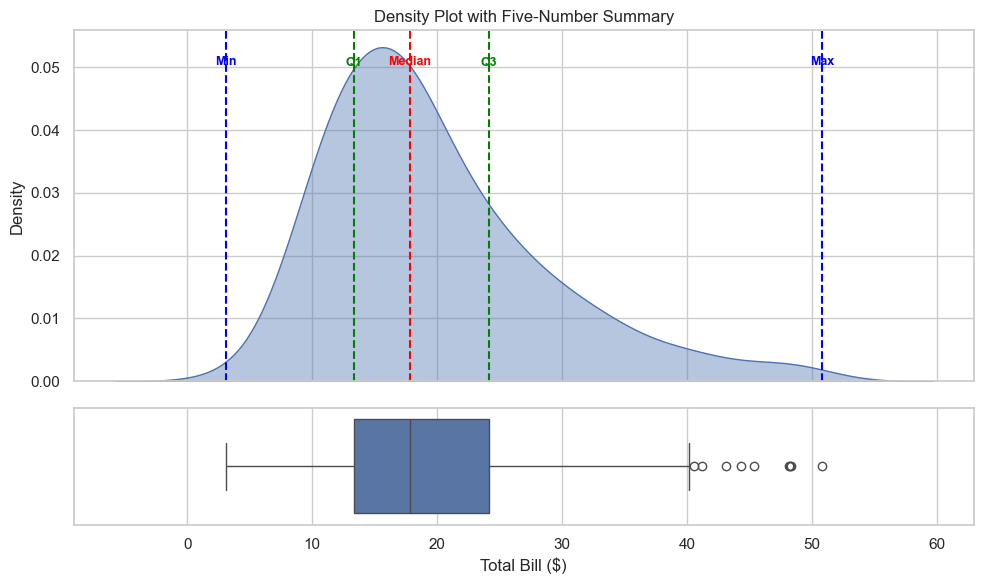

In [8]:
# Show the density plot with the five-number summary marked,
# and a box plot directly below it
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6),
                                sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})

# Top: density plot with vertical lines for the 5-number summary
sns.kdeplot(data=tips, x='total_bill', fill=True, alpha=0.4, ax=ax1)

colors = ['blue', 'green', 'red', 'green', 'blue']
labels = ['Min', 'Q1', 'Median', 'Q3', 'Max']
values = five_num.values

for val, color, label in zip(values, colors, labels):
    ax1.axvline(x=val, color=color, linestyle='--', linewidth=1.5)
    ax1.text(val, ax1.get_ylim()[1] * 0.9, label, ha='center', fontsize=9,
             color=color, fontweight='bold')

ax1.set_title('Density Plot with Five-Number Summary')
ax1.set_ylabel('Density')

# Bottom: box plot
sns.boxplot(data=tips, x='total_bill', ax=ax2)
ax2.set_xlabel('Total Bill ($)')

plt.tight_layout()
plt.show()

**Connection:** Notice how the box in the box plot spans from Q1 to Q3 (the middle 50% of the data), the line inside is the median (Q2), and the whiskers extend to roughly the min and max (excluding outliers). The box plot is a compact summary of the density curve above it.

> This is essentially what animation 5.1.3 in the book shows -- data points stacking into a histogram, then collapsing into a box plot.

#### Quick Quiz: Which box plot could be from a Normal distribution?

Think about what a Normal (bell-shaped) distribution looks like:
- Symmetric around the mean
- Q1 and Q3 are roughly equidistant from the median
- Whiskers are roughly equal length

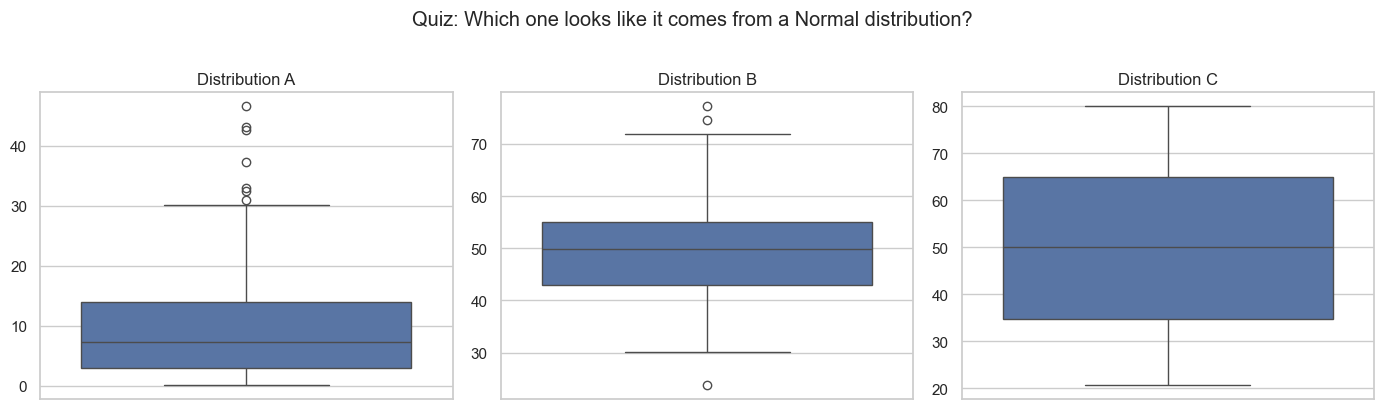

In [9]:
# Generate three different distributions
np.random.seed(42)

data_normal = np.random.normal(loc=50, scale=10, size=200)      # symmetric
data_skewed = np.random.exponential(scale=10, size=200)          # right-skewed
data_uniform = np.random.uniform(low=20, high=80, size=200)      # flat/uniform

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, data, title in zip(axes,
                            [data_skewed, data_normal, data_uniform],
                            ['Distribution A', 'Distribution B', 'Distribution C']):
    sns.boxplot(y=data, ax=ax)
    ax.set_title(title)

plt.suptitle('Quiz: Which one looks like it comes from a Normal distribution?', y=1.02)
plt.tight_layout()
plt.show()

<details>
<summary><b>Click to reveal answer</b></summary>

**Distribution B** -- it is roughly symmetric with equal whisker lengths and the median is centered in the box. Distribution A is right-skewed (long upper whisker, many outliers on top). Distribution C is uniform (very short whiskers relative to box, no outliers).

</details>

---
## Part 2: Visualizing Data with Multiple Features (Section 5.2)

When we have **two or more features**, the visualization changes depending on the **type** of each feature.

### Reference Table: Choosing the Right Plot

#### Plots for 1 Feature

| Feature Type | Recommended Plot(s) |
|-------------|---------------------|
| 1 categorical | Bar chart, pie chart (avoid pie charts though!) |
| 1 numerical | Histogram, density plot (KDE), box plot |

#### Plots for 2 Features

| Feature Types | Recommended Plot(s) |
|--------------|---------------------|
| 2 numerical | Scatter plot |
| 2 categorical | Stacked bar chart, grouped bar chart |
| 1 categorical + 1 numerical | Box plot, violin plot, bar plot (of means) |

#### More than 2 Features

The screen only has 2 spatial dimensions! So we use additional visual channels:

| Channel | Works for |
|---------|-----------|
| **Color** | Categorical or numerical |
| **Size** | Numerical |
| **Shape** | Categorical |
| **Transparency** | Numerical |
| **Faceting** (side-by-side plots) | Categorical |

### 2.1 Two Numerical Features: Scatter Plot

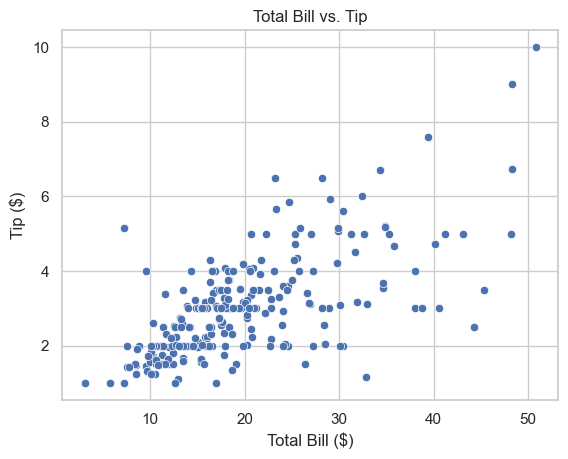

In [10]:
# Scatter plot: total_bill vs tip
sns.scatterplot(data=tips, x='total_bill', y='tip')
plt.title('Total Bill vs. Tip')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.show()

As the total bill increases, so does the tip -- this makes sense since tips are usually a percentage of the bill.

### 2.2 Two Categorical Features: Grouped Bar Chart

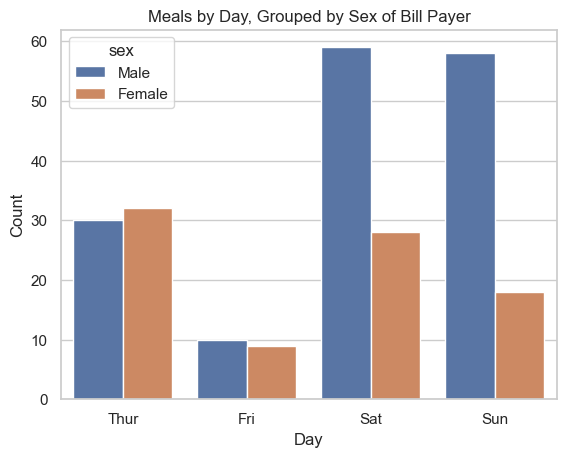

In [11]:
# Grouped bar chart: day vs count, colored by sex
sns.countplot(data=tips, x='day', hue='sex', order=['Thur', 'Fri', 'Sat', 'Sun'])
plt.title('Meals by Day, Grouped by Sex of Bill Payer')
plt.xlabel('Day')
plt.ylabel('Count')
plt.show()

### 2.3 One Categorical + One Numerical: Box Plot & Violin Plot

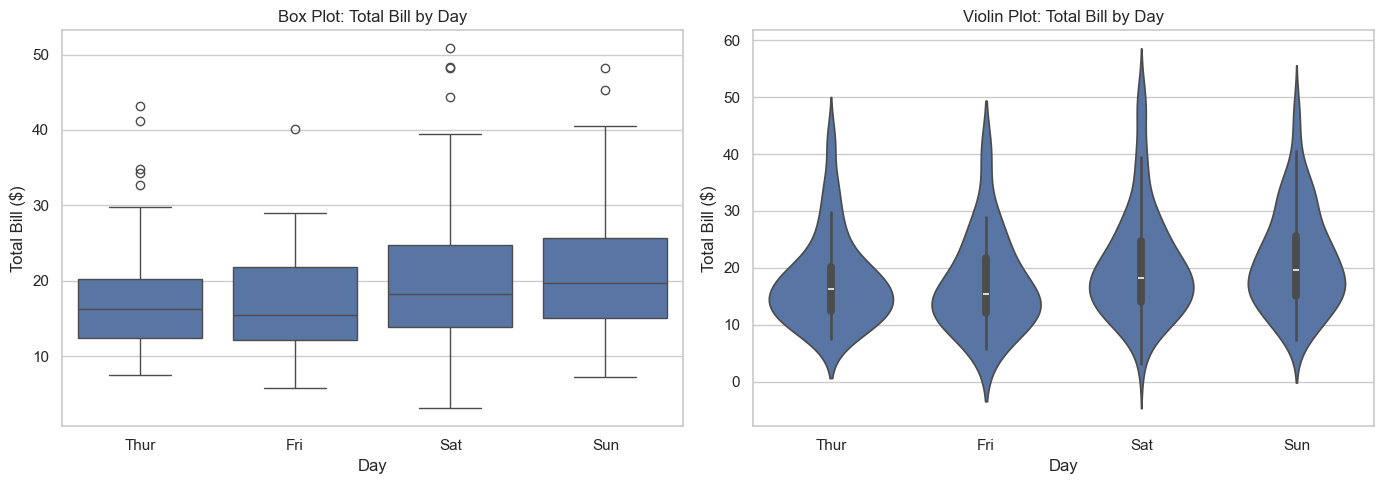

In [12]:
# Box plot: total_bill by day
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=tips, x='day', y='total_bill',
            order=['Thur', 'Fri', 'Sat', 'Sun'], ax=ax1)
ax1.set_title('Box Plot: Total Bill by Day')
ax1.set_xlabel('Day')
ax1.set_ylabel('Total Bill ($)')

# Violin plot: same data -- shows the full distribution shape
sns.violinplot(data=tips, x='day', y='total_bill',
              order=['Thur', 'Fri', 'Sat', 'Sun'], ax=ax2)
ax2.set_title('Violin Plot: Total Bill by Day')
ax2.set_xlabel('Day')
ax2.set_ylabel('Total Bill ($)')

plt.tight_layout()
plt.show()

The **violin plot** is like a box plot + density plot combined. It shows the full distribution shape, not just the five-number summary.

### 2.4 More Than Two Features: Color, Size, and Faceting

With more than two features, the screen cannot display enough axes. We use **color**, **size**, **transparency**, and **faceting** to encode extra information.

> **Think about it first:** If I give you a scatter plot of total_bill vs tip, how could you also show which day each meal happened and whether the party had smokers?

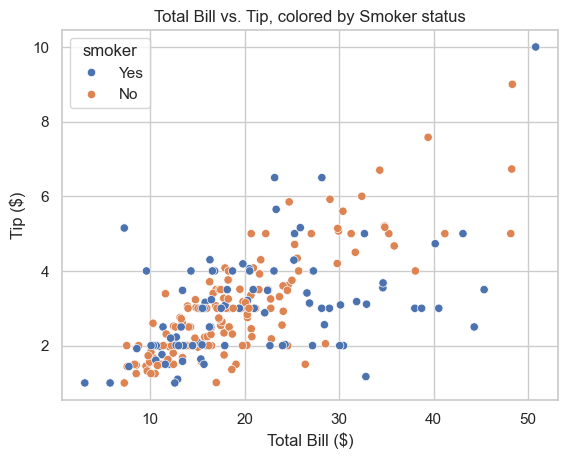

In [13]:
# Adding a 3rd feature with color (hue)
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='smoker')
plt.title('Total Bill vs. Tip, colored by Smoker status')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.show()

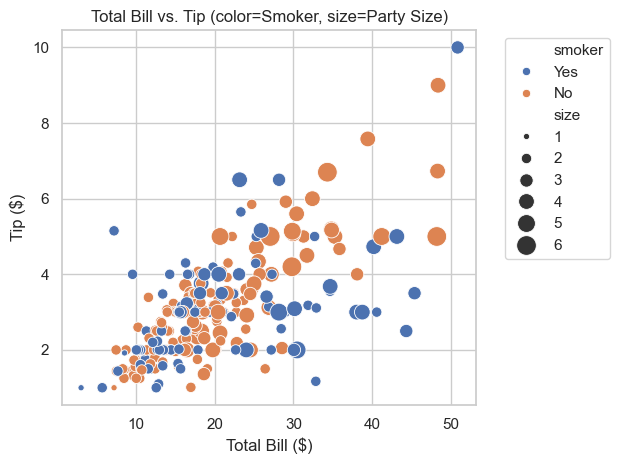

In [14]:
# Adding a 4th feature with size
sns.scatterplot(data=tips, x='total_bill', y='tip',
                hue='smoker', size='size',
                sizes=(20, 200))
plt.title('Total Bill vs. Tip (color=Smoker, size=Party Size)')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

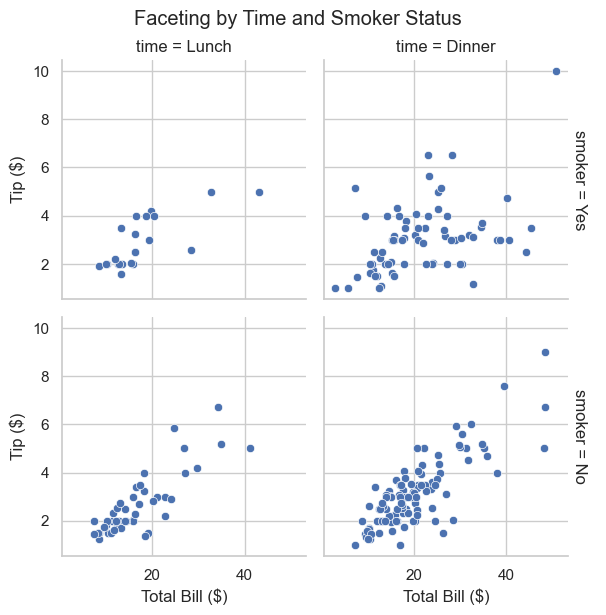

In [15]:
# Faceting: create separate plots for each value of a categorical feature
# This is very powerful for categorical comparisons
g = sns.FacetGrid(tips, col='time', row='smoker', margin_titles=True)
g.map_dataframe(sns.scatterplot, x='total_bill', y='tip')
g.set_axis_labels('Total Bill ($)', 'Tip ($)')
g.add_legend()
plt.suptitle('Faceting by Time and Smoker Status', y=1.02)
plt.show()

**Faceting** is the practice of displaying multiple plots side by side in an array where one feature changes from plot to plot. It is especially useful for categorical features.

#### Quiz: Which plot is the best fit for the job?

For each scenario below, choose the most appropriate plot type:

1. You want to show the **distribution of income** across a population.
   - (a) Bar chart  (b) Histogram  (c) Scatter plot

2. You want to compare **average salary** across 4 departments.
   - (a) Scatter plot  (b) Box plot  (c) Line chart

3. You have **height vs weight** and want to see the relationship.
   - (a) Bar chart  (b) Histogram  (c) Scatter plot

4. You want to see the **count of students** in each major, split by gender.
   - (a) Grouped bar chart  (b) Scatter plot  (c) Density plot

5. You want to understand the **full shape of test score distributions** for 3 class sections.
   - (a) Bar chart  (b) Violin plot  (c) Scatter plot

<details>
<summary><b>Click to reveal answers</b></summary>

1. **(b) Histogram** -- income is numerical, we want its distribution.
2. **(b) Box plot** -- 1 categorical (department) + 1 numerical (salary). A bar plot of means would also work, but box plot shows the spread too.
3. **(c) Scatter plot** -- 2 numerical features.
4. **(a) Grouped bar chart** -- 2 categorical features (major, gender).
5. **(b) Violin plot** -- 1 categorical (section) + 1 numerical (score), and we want the full shape.

</details>

---
## Part 3: Best Practices for Visualizing Data (Section 5.3)

The book highlights several common mistakes. Let's see them hands-on.

### 3.1 Misleading Scales: The Bar Chart Problem

Bar charts should **always start the y-axis at zero**. If they don't, small differences look huge.

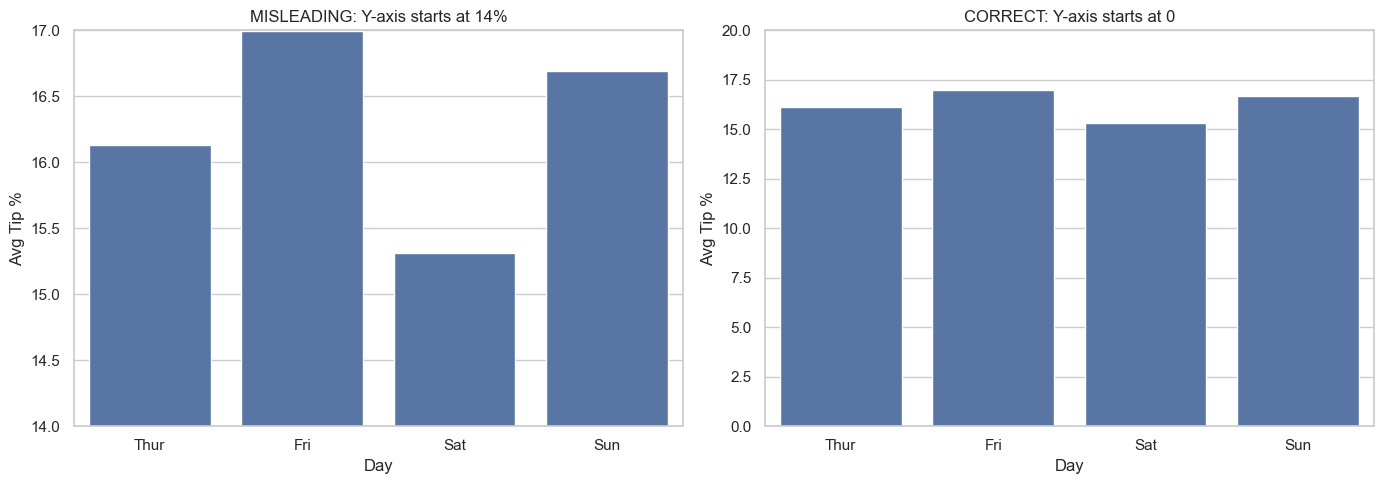

In [16]:
# Average tip percentage by day
tips['tip_pct'] = tips['tip'] / tips['total_bill'] * 100
day_order = ['Thur', 'Fri', 'Sat', 'Sun']
avg_tip_by_day = tips.groupby('day')['tip_pct'].mean().reindex(day_order)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# BAD: y-axis does not start at zero
sns.barplot(x=avg_tip_by_day.index, y=avg_tip_by_day.values, ax=ax1)
ax1.set_ylim(14, 17)  # <-- misleading!
ax1.set_title('MISLEADING: Y-axis starts at 14%')
ax1.set_xlabel('Day')
ax1.set_ylabel('Avg Tip %')

# GOOD: y-axis starts at zero
sns.barplot(x=avg_tip_by_day.index, y=avg_tip_by_day.values, ax=ax2)
ax2.set_ylim(0, 20)
ax2.set_title('CORRECT: Y-axis starts at 0')
ax2.set_xlabel('Day')
ax2.set_ylabel('Avg Tip %')

plt.tight_layout()
plt.show()

**Look at the left plot**: Friday looks like it has *way* more tips than Sunday. But the actual difference is tiny!

**Rule:** Bar charts should always include 0 on the value axis. Scales should not be altered to exaggerate differences.

### Quiz: What is wrong with this plot? Fix it!

Look at the plot below. Identify the problem and think about how to fix it.

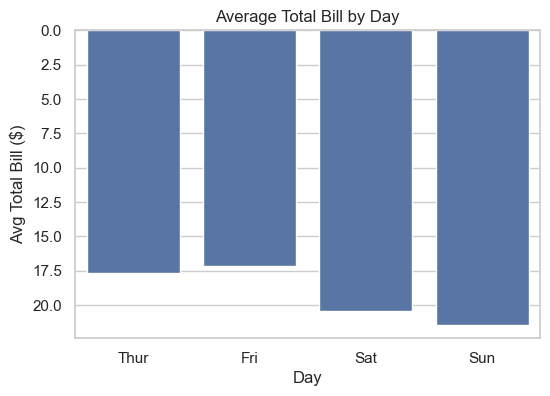

In [17]:
# A bar chart with issues -- can you spot the problem?
avg_bill_by_day = tips.groupby('day')['total_bill'].mean().reindex(day_order)

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=avg_bill_by_day.index, y=avg_bill_by_day.values, ax=ax)
ax.set_ylim(avg_bill_by_day.max() + 1, 0)  # <-- upside down!
ax.set_title('Average Total Bill by Day')
ax.set_xlabel('Day')
ax.set_ylabel('Avg Total Bill ($)')
plt.show()

<details>
<summary><b>Click to reveal what's wrong</b></summary>

The y-axis is **upside down**! The scale goes from high at the bottom to low at the top. This makes Sunday look like the cheapest day, when it's actually the most expensive. The convention is that **up and to the right** should be the positive direction.

</details>

### 3.2 Color Considerations

- About **8% of males** have color-vision deficiency (CVD), mostly red-green.
- Avoid using **only red vs green** to distinguish categories.
- Use colorblind-friendly palettes. Seaborn has `colorblind` palette built in.

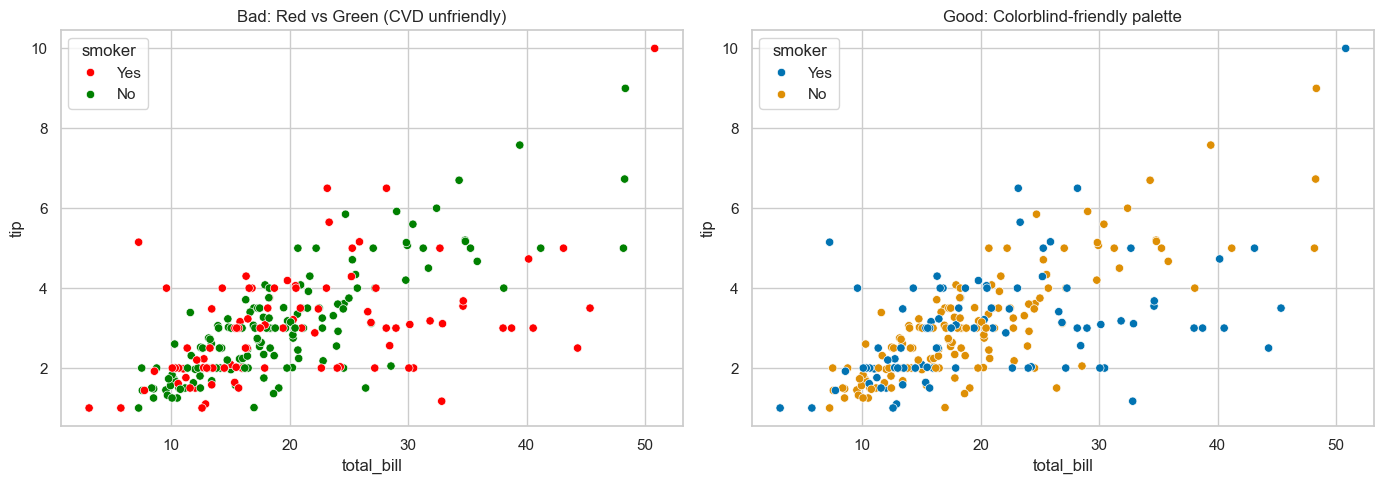

In [18]:
# Comparison: default vs colorblind-friendly palette
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Default palette
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='smoker',
                palette=['red', 'green'], ax=ax1)
ax1.set_title('Bad: Red vs Green (CVD unfriendly)')

# Colorblind-friendly palette
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='smoker',
                palette='colorblind', ax=ax2)
ax2.set_title('Good: Colorblind-friendly palette')

plt.tight_layout()
plt.show()

---
## Part 4: Exploratory Data Analysis -- EDA (Section 5.5)

**Exploratory Data Analysis (EDA)** is the process of investigating a dataset to understand what is in it.

### The Four Steps of EDA

| Step | Description | Key Tools |
|------|-------------|----------|
| **1. Understand the data** | Size, feature names, types (categorical vs numerical) | `df.shape`, `df.info()`, `df.dtypes` |
| **2. Identify relationships** | Direction and strength of correlations | Scatter plots, `df.corr()`, heatmap |
| **3. Describe the shape** | Symmetric vs skewed distributions | Histograms, KDE plots |
| **4. Detect outliers & missing data** | Values far from the rest, missing entries | Box plots, `df.isna().sum()` |

Let's walk through all four steps with a real dataset.

In [20]:
# We will use the penguins dataset (also used in the book's case study 5.7)
penguins = sns.load_dataset('penguins')
print('Dataset shape:', penguins.shape)
penguins.head()

Dataset shape: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


### Step 1: Understand the Data

How many rows? Columns? Which features are categorical? Numerical?

In [21]:
# Basic info
print(f'Rows: {penguins.shape[0]}, Columns: {penguins.shape[1]}')
print()
penguins.info()

Rows: 344, Columns: 7

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


In [22]:
# Classify each feature
print('Numerical features:')
print(list(penguins.select_dtypes(include='number').columns))
print()
print('Categorical features:')
print(list(penguins.select_dtypes(include='object').columns))

Numerical features:
['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

Categorical features:
['species', 'island', 'sex']


In [23]:
# Summary statistics
penguins.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


### Step 2: Identify Relationships Between Features

**Correlation** describes the strength and direction of a linear relationship between numerical features.
- Positive correlation: as one goes up, the other goes up
- Negative correlation: as one goes up, the other goes down
- No correlation: no linear pattern

In [24]:
# Correlation matrix
corr_matrix = penguins.select_dtypes(include='number').corr()
print(corr_matrix.round(2))

                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm               1.00          -0.24               0.66   
bill_depth_mm               -0.24           1.00              -0.58   
flipper_length_mm            0.66          -0.58               1.00   
body_mass_g                  0.60          -0.47               0.87   

                   body_mass_g  
bill_length_mm            0.60  
bill_depth_mm            -0.47  
flipper_length_mm         0.87  
body_mass_g               1.00  


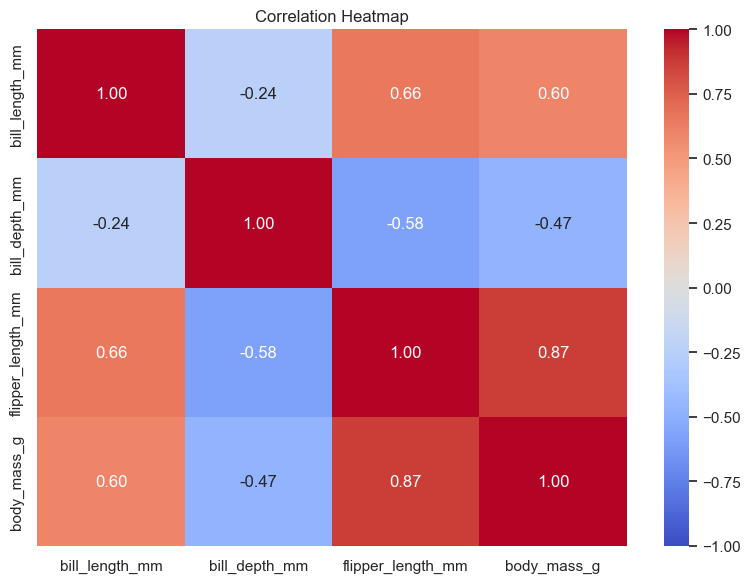

In [25]:
# Heatmap of correlations
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

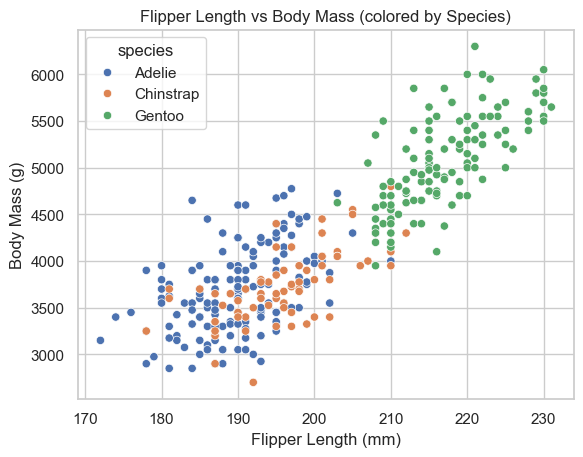

In [26]:
# Scatter plot of the two most correlated features
sns.scatterplot(data=penguins, x='flipper_length_mm', y='body_mass_g', hue='species')
plt.title('Flipper Length vs Body Mass (colored by Species)')
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Body Mass (g)')
plt.show()

**Observation:** Flipper length and body mass have a strong positive correlation (~0.87). The species also cluster nicely -- Gentoo penguins tend to be larger.

#### Scatter Matrix (Pair Plot)

Instead of making scatter plots one pair at a time, we can use a **scatter matrix** (also called a pair plot) to see the relationships between **all** numerical features at once. The diagonal shows each feature's distribution.

In [ ]:
# Scatter matrix / pair plot -- see all pairwise relationships at once
sns.pairplot(penguins, hue='species', diag_kind='kde')
plt.suptitle('Scatter Matrix (Pair Plot) -- colored by Species', y=1.02)
plt.show()

**How to read the scatter matrix:**
- Each **off-diagonal** cell is a scatter plot of two features. Look for linear trends (positive/negative correlation) or clusters.
- Each **diagonal** cell shows the distribution (KDE) of a single feature, split by species.
- The color (hue) lets us see how the three species separate across different feature combinations.

### Step 3: Describe the Shape of the Data

Distributions can be:
- **Symmetric**: roughly mirror image on both sides of the center (e.g., Normal)
- **Right-skewed** (positively skewed): long tail on the right
- **Left-skewed** (negatively skewed): long tail on the left

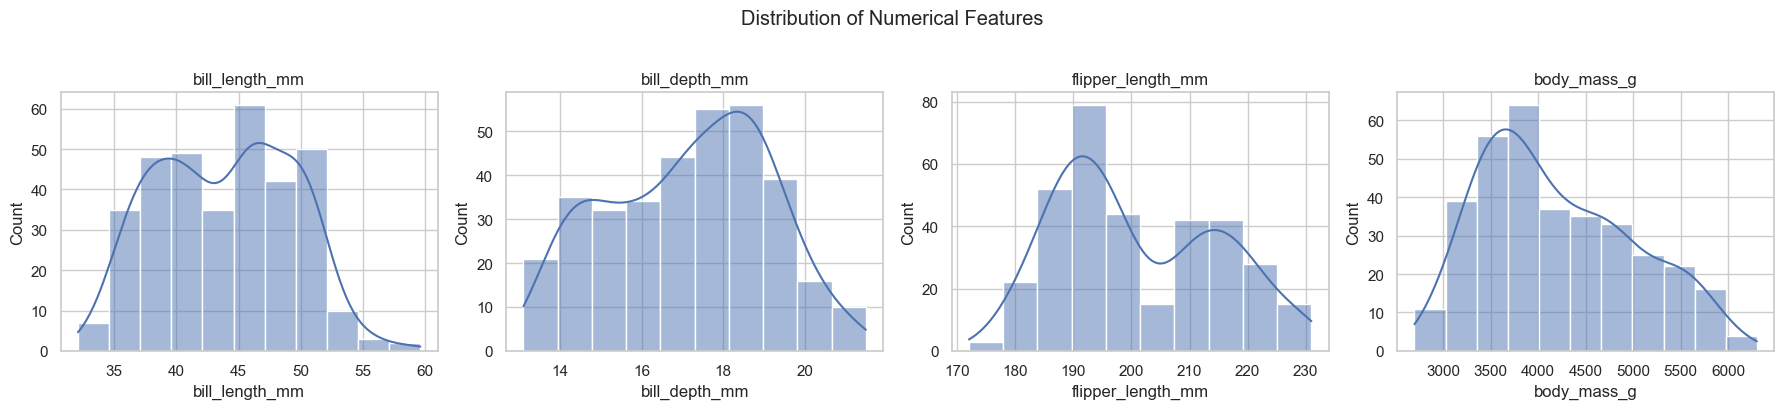

In [27]:
# Distribution of each numerical feature
num_cols = penguins.select_dtypes(include='number').columns

fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 4))

for ax, col in zip(axes, num_cols):
    sns.histplot(data=penguins, x=col, kde=True, ax=ax)
    ax.set_title(col)

plt.suptitle('Distribution of Numerical Features', y=1.02)
plt.tight_layout()
plt.show()

**Observations:**
- `body_mass_g` appears roughly right-skewed (or bimodal due to species differences).
- Some features show bimodal patterns -- this is a hint that there may be **subgroups** (species!) in the data.

### Step 4: Detect Outliers and Missing Data

In [28]:
# Missing data
print('Missing values per column:')
print(penguins.isna().sum())
print()
print(f'Total missing: {penguins.isna().sum().sum()} out of {penguins.size} values')

Missing values per column:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Total missing: 19 out of 2408 values


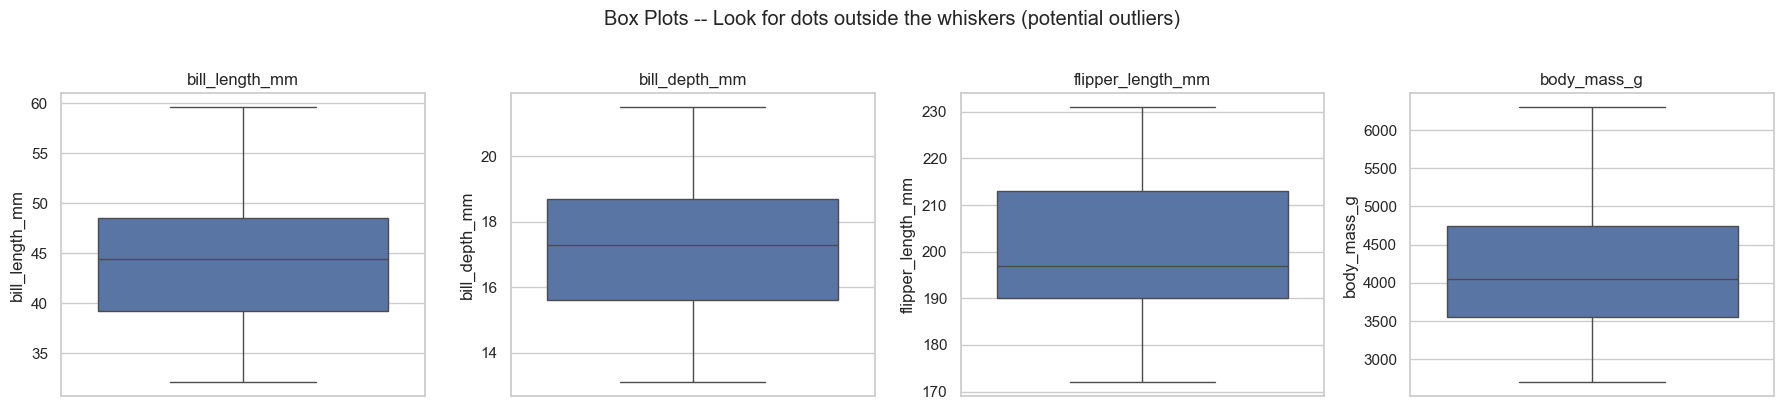

In [29]:
# Box plots to spot outliers
fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 4))

for ax, col in zip(axes, num_cols):
    sns.boxplot(data=penguins, y=col, ax=ax)
    ax.set_title(col)

plt.suptitle('Box Plots -- Look for dots outside the whiskers (potential outliers)', y=1.02)
plt.tight_layout()
plt.show()

**Types of missing data** (from the book):
- **MCAR** (Missing Completely At Random): missingness is random.
- **MAR** (Missing At Random): missingness depends on other observed features.
- **MNAR** (Missing Not At Random): missingness depends on the missing value itself.

---
## Part 5: Detecting Outliers (Section 5.6)

An **outlier** is an instance that is separated from the rest of the dataset.

### Why do outliers matter?
- They can **distort** the mean and standard deviation.
- They can **change** a linear model significantly.
- Key terms:
  - **Leverage**: a point's *potential* for changing a model (far out in the feature space).
  - **Influential point**: a high-leverage point that *actually does* change the model a lot.
  - Not all high-leverage points are influential!

### Two Parametric Methods for Detecting Outliers

| Method | Rule | When to use |
|--------|------|-------------|
| **Tukey's Fences** | Outlier if value < Q1 - 1.5*IQR or > Q3 + 1.5*IQR | General purpose, does not assume normality |
| **Z-score** | Outlier if abs(z-score) > 3 | Assumes roughly normal distribution |

### 5.1 Impact of Outliers on a Linear Model

Let's see how a single outlier can change a regression line.

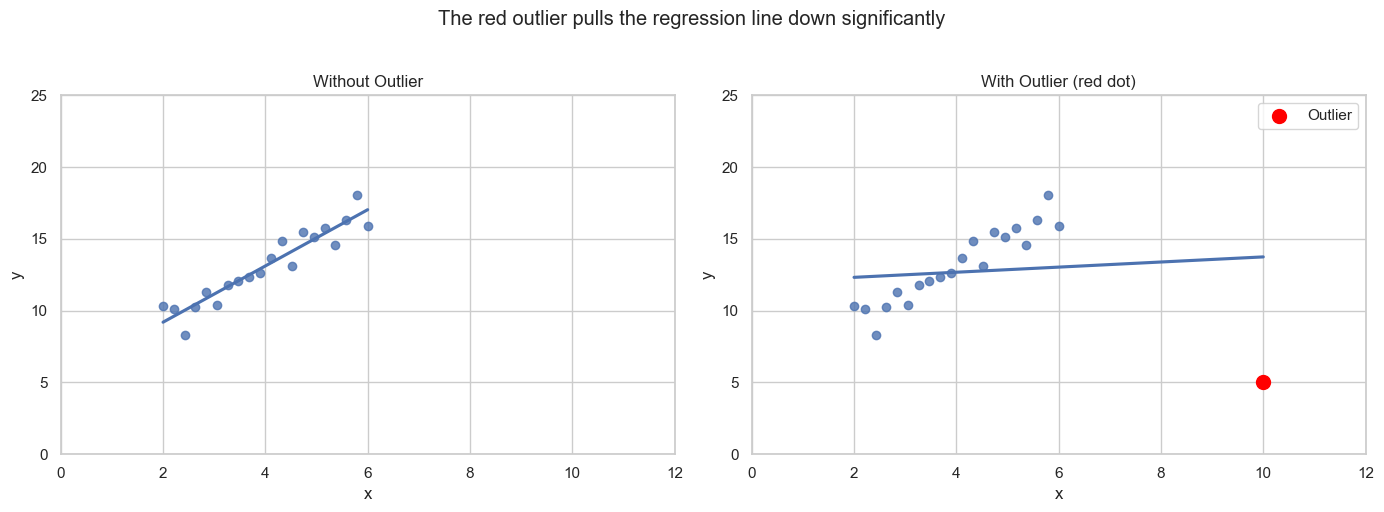

In [30]:
# Create a small clean dataset
np.random.seed(10)
x = np.linspace(2, 6, 20)
y = 2 * x + 5 + np.random.normal(0, 1, 20)

df_clean = pd.DataFrame({'x': x, 'y': y})

# Add an outlier -- a high-leverage influential point
df_outlier = pd.concat([df_clean, pd.DataFrame({'x': [10], 'y': [5]})],
                       ignore_index=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Without outlier
sns.regplot(data=df_clean, x='x', y='y', ax=ax1, ci=None)
ax1.set_title('Without Outlier')
ax1.set_xlim(0, 12)
ax1.set_ylim(0, 25)

# With outlier
sns.regplot(data=df_outlier, x='x', y='y', ax=ax2, ci=None)
ax2.scatter([10], [5], color='red', s=100, zorder=5, label='Outlier')
ax2.set_title('With Outlier (red dot)')
ax2.set_xlim(0, 12)
ax2.set_ylim(0, 25)
ax2.legend()

plt.suptitle('The red outlier pulls the regression line down significantly', y=1.02)
plt.tight_layout()
plt.show()

**Observation:** The red point at (10, 5) is both a **high-leverage point** (far out on x-axis) and an **influential point** (it dramatically changes the slope of the regression line).

### 5.2 Tukey's Fences

**IQR** = Q3 - Q1 (the interquartile range)

A value is an outlier if:
- value < Q1 - 1.5 * IQR  (lower fence)
- value > Q3 + 1.5 * IQR  (upper fence)

This is exactly what the box plot whiskers use!

In [31]:
# Tukey's Fences for the tips dataset: total_bill
Q1 = tips['total_bill'].quantile(0.25)
Q3 = tips['total_bill'].quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print(f'Q1 = {Q1:.2f}')
print(f'Q3 = {Q3:.2f}')
print(f'IQR = {IQR:.2f}')
print(f'Lower Fence = {lower_fence:.2f}')
print(f'Upper Fence = {upper_fence:.2f}')
print()

# Find outliers
outliers = tips[(tips['total_bill'] < lower_fence) | (tips['total_bill'] > upper_fence)]
print(f'Number of outliers: {len(outliers)}')
print(outliers[['total_bill', 'tip', 'day']].sort_values('total_bill', ascending=False))

Q1 = 13.35
Q3 = 24.13
IQR = 10.78
Lower Fence = -2.82
Upper Fence = 40.30

Number of outliers: 9
     total_bill    tip   day
170       50.81  10.00   Sat
212       48.33   9.00   Sat
59        48.27   6.73   Sat
156       48.17   5.00   Sun
182       45.35   3.50   Sun
102       44.30   2.50   Sat
197       43.11   5.00  Thur
142       41.19   5.00  Thur
184       40.55   3.00   Sun


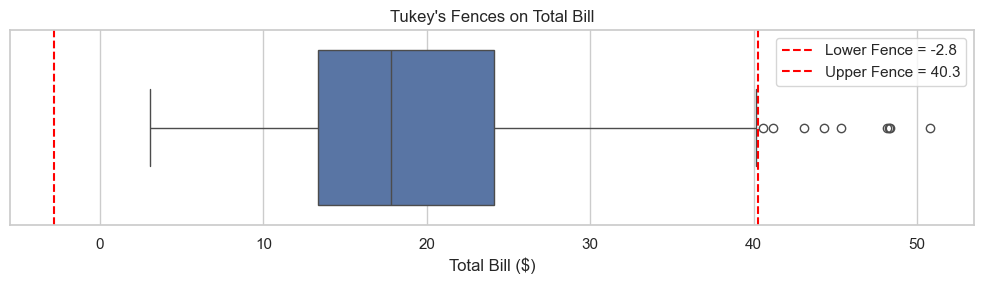

In [32]:
# Visualize the fences on a box plot
fig, ax = plt.subplots(figsize=(10, 3))
sns.boxplot(data=tips, x='total_bill', ax=ax)

ax.axvline(x=lower_fence, color='red', linestyle='--', label=f'Lower Fence = {lower_fence:.1f}')
ax.axvline(x=upper_fence, color='red', linestyle='--', label=f'Upper Fence = {upper_fence:.1f}')
ax.legend()
ax.set_title("Tukey's Fences on Total Bill")
ax.set_xlabel('Total Bill ($)')
plt.tight_layout()
plt.show()

### 5.3 Z-Score Method

The z-score measures how many standard deviations a value is from the mean.

$$z = \frac{x - \mu}{\sigma}$$

A value is considered an outlier if **|z| > 3** (i.e., more than 3 standard deviations from the mean).

This assumes the data is roughly normally distributed.

In [33]:
# Z-score method for total_bill
mean_bill = tips['total_bill'].mean()
std_bill = tips['total_bill'].std()

tips['z_score_bill'] = (tips['total_bill'] - mean_bill) / std_bill

print(f'Mean = {mean_bill:.2f}')
print(f'Std Dev = {std_bill:.2f}')
print()

# Find outliers with |z| > 3
z_outliers = tips[tips['z_score_bill'].abs() > 3]
print(f'Outliers by z-score (|z| > 3): {len(z_outliers)}')
print(z_outliers[['total_bill', 'z_score_bill']])
print()

# Compare: outliers with |z| > 2 (less strict)
z_outliers_2 = tips[tips['z_score_bill'].abs() > 2]
print(f'Outliers by z-score (|z| > 2): {len(z_outliers_2)}')

Mean = 19.79
Std Dev = 8.90

Outliers by z-score (|z| > 3): 4
     total_bill  z_score_bill
59        48.27      3.199589
156       48.17      3.188356
170       50.81      3.484905
212       48.33      3.206329

Outliers by z-score (|z| > 2): 14


### Comparing Tukey's Fences vs Z-Score

Both methods identify outliers, but they use different logic:
- **Tukey's Fences**: based on quartiles (robust to extreme values).
- **Z-score**: based on mean and std dev (sensitive to extreme values, assumes normality).

Neither is "better" -- the choice depends on your data and assumptions.

In [34]:
# Clean up the temporary column
tips = tips.drop(columns=['z_score_bill', 'tip_pct'])

---
## Summary

### What we covered today:

| Topic | Key Takeaway |
|-------|-------------|
| **5.1 - One feature** | Bar charts for categorical, histograms/density/box plots for numerical |
| **5.2 - Multiple features** | Scatter plots (2 num), grouped bar charts (2 cat), box/violin plots (cat+num) |
| **5.3 - Best practices** | Start bars at zero, use colorblind-friendly palettes, avoid pie charts |
| **5.5 - EDA** | 4 steps: understand data, find relationships, describe shape, detect outliers |
| **5.6 - Outliers** | Tukey's Fences (IQR-based) and z-scores (mean/std based) |


### Key seaborn functions used today:

| Function | Purpose |
|----------|--------|
| `sns.countplot()` | Bar chart of counts |
| `sns.barplot()` | Bar chart of a statistic (mean by default) |
| `sns.histplot()` | Histogram |
| `sns.kdeplot()` | Density (KDE) plot |
| `sns.boxplot()` | Box plot |
| `sns.violinplot()` | Violin plot |
| `sns.scatterplot()` | Scatter plot |
| `sns.heatmap()` | Heatmap (for correlation matrices) |
| `sns.pairplot()` | Scatter matrix (all pairwise relationships) |
| `sns.regplot()` | Scatter plot with regression line |
| `sns.FacetGrid()` | Faceted (small multiples) plots |